# 04 — Interpretação dos Resultados

Interpretação dos coeficientes via exp(b) e diagnóstico do modelo.

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import NegativeBinomial as NB_MLE
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import json, warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("../data/dataset_vendedores.csv")
coefs = pd.read_csv("../outputs/coeficientes_negbin.csv", index_col=0)
with open("../outputs/metricas_modelos.json") as f:
    metricas = json.load(f)

print(f"Variaveis no modelo final: {len(coefs)} coeficientes")
print(coefs[["coef","exp_coef","p_value"]].to_string())

Variaveis no modelo final: 7 coeficientes
                                     coef  exp_coef        p_value
const                           -1.780220  0.168601  3.062277e-222
atraso_medio                     0.043512  1.044473   1.925883e-26
frete_medio                      0.005558  1.005574   1.512660e-09
cat_group_bed_bath_table         0.288097  1.333887   7.858178e-07
cat_group_computers_accessories  0.189360  1.208476   1.620210e-03
cat_group_furniture_decor        0.256289  1.292126   1.136753e-05
cat_group_telephony              0.323730  1.382274   9.360453e-05


## 1. Interpretação via exp(b)

Com offset log(n_reviews), os coeficientes modelam a **taxa** de reviews negativos.
exp(b) indica o fator multiplicativo sobre a taxa para cada unidade de aumento em X.

In [2]:
coefs["pct_change"] = (coefs["exp_coef"] - 1) * 100

interp = coefs.drop(["const"], errors="ignore").copy()
interp = interp[interp["p_value"] < 0.05].sort_values("exp_coef", ascending=False)

print("=== Efeitos significativos ===")
fmt = "{:<40s} {:>8s} {:>8s} {:>10s} {:>10s}"
print(fmt.format("Variavel", "Coef", "exp(b)", "Efeito %", "p-valor"))
print("-" * 80)
for idx, row in interp.iterrows():
    sinal = "+" if row["pct_change"] > 0 else ""
    print(f"{idx:<40s} {row['coef']:>8.4f} {row['exp_coef']:>8.4f} {sinal}{row['pct_change']:>9.2f}% {row['p_value']:>10.2e}")

=== Efeitos significativos ===
Variavel                                     Coef   exp(b)   Efeito %    p-valor
--------------------------------------------------------------------------------
cat_group_telephony                        0.3237   1.3823 +    38.23%   9.36e-05
cat_group_bed_bath_table                   0.2881   1.3339 +    33.39%   7.86e-07
cat_group_furniture_decor                  0.2563   1.2921 +    29.21%   1.14e-05
cat_group_computers_accessories            0.1894   1.2085 +    20.85%   1.62e-03
atraso_medio                               0.0435   1.0445 +     4.45%   1.93e-26
frete_medio                                0.0056   1.0056 +     0.56%   1.51e-09


## 2. Visualização dos coeficientes

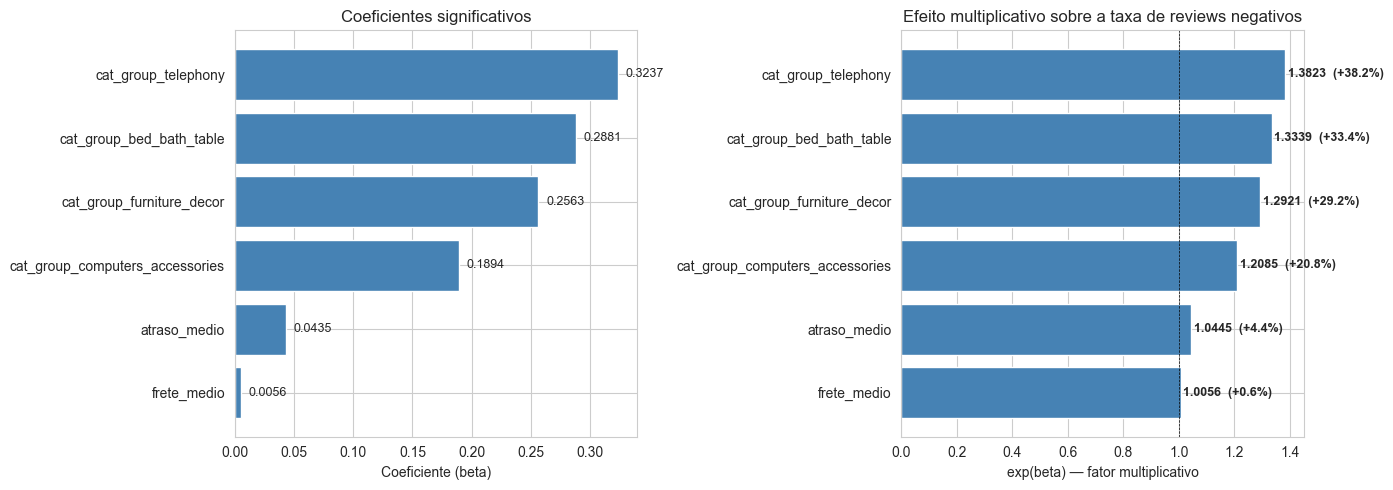

In [3]:
interp_sorted = interp.sort_values("coef")

fig, axes = plt.subplots(1, 2, figsize=(14, max(5, len(interp_sorted)*0.6)))

colors = ["steelblue" if c > 0 else "coral" for c in interp_sorted["coef"]]
bars1 = axes[0].barh(interp_sorted.index, interp_sorted["coef"], color=colors, edgecolor="white")
axes[0].axvline(0, color="black", linewidth=0.5)
axes[0].set_xlabel("Coeficiente (beta)")
axes[0].set_title("Coeficientes significativos")
max_coef = interp_sorted["coef"].abs().max()
for bar, val in zip(bars1, interp_sorted["coef"]):
    offset = max_coef * 0.02
    axes[0].text(bar.get_width() + (offset if val >= 0 else -offset),
                 bar.get_y() + bar.get_height()/2,
                 f"{val:.4f}", va="center",
                 ha="left" if val >= 0 else "right", fontsize=9)

colors2 = ["steelblue" if c > 1 else "coral" for c in interp_sorted["exp_coef"]]
bars2 = axes[1].barh(interp_sorted.index, interp_sorted["exp_coef"], color=colors2, edgecolor="white")
axes[1].axvline(1, color="black", linewidth=0.5, linestyle="--")
axes[1].set_xlabel("exp(beta) — fator multiplicativo")
axes[1].set_title("Efeito multiplicativo sobre a taxa de reviews negativos")
for bar, val in zip(bars2, interp_sorted["exp_coef"]):
    pct = (val - 1) * 100
    sinal = "+" if pct > 0 else ""
    axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f"{val:.4f}  ({sinal}{pct:.1f}%)", va="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("../outputs/interp_coeficientes.png", bbox_inches="tight", dpi=110)
plt.show()

## 3. Efeitos marginais médios (AME)

Complementa a interpretação por exp(β) traduzindo os coeficientes em variação esperada na contagem absoluta de reviews negativos para o vendedor médio da amostra.

In [4]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import NegativeBinomial as NB_MLE

_df = pd.read_csv("../data/dataset_vendedores.csv")
_cat_counts = _df["categoria_principal"].value_counts()
_cats_keep = _cat_counts[_cat_counts >= 30].index.tolist()
_df["cat_group"] = _df["categoria_principal"].where(_df["categoria_principal"].isin(_cats_keep), "other")
_st_counts = _df["seller_state"].value_counts()
_st_keep = _st_counts[_st_counts >= 30].index.tolist()
_df["state_group"] = _df["seller_state"].where(_df["seller_state"].isin(_st_keep), "other")
_df["log_n_reviews"] = np.log(_df["n_reviews"])

_df_model = _df[[
    "n_negative", "log_n_reviews", "atraso_medio", "ticket_medio",
    "frete_medio", "peso_medio", "cat_group", "state_group",
]].copy()
_df_model = pd.get_dummies(_df_model, columns=["cat_group", "state_group"], dtype=int)
_df_model = _df_model.drop(columns=["cat_group_sports_leisure", "state_group_SP"])

_y = _df_model["n_negative"]
_offset = _df_model["log_n_reviews"]
_X = sm.add_constant(_df_model.drop(columns=["n_negative", "log_n_reviews"]))
_cols_red = [
    "const", "atraso_medio", "frete_medio",
    "cat_group_bed_bath_table", "cat_group_computers_accessories",
    "cat_group_furniture_decor", "cat_group_telephony",
]
_X_red = _X[_cols_red]
_negbin = NB_MLE(_y, _X_red, exposure=np.exp(_offset)).fit(method="bfgs", maxiter=500, disp=False)

_mu_obs = _negbin.predict(_X_red, exposure=np.exp(_offset))
ame = {}
for var in ["atraso_medio", "frete_medio"]:
    coef = _negbin.params[var]
    ame[var] = float((_mu_obs * coef).mean())

print(f"AME atraso_medio: {ame['atraso_medio']:.4f} reviews negativos por dia")
print(f"AME frete_medio:  {ame['frete_medio']:.4f} reviews negativos por R$")


AME atraso_medio: 0.2928 reviews negativos por dia
AME frete_medio:  0.0374 reviews negativos por R$


## 4. Tabela comparativa

In [5]:
print("=== Comparacao final ===")
fmt = "{:<20s} {:>15s} {:>15s} {:>15s}"
print(fmt.format("", "Poisson", "NB2 Completo", "NB2 Reduzido"))
print("-" * 68)
for key, label in [("aic", "AIC"), ("bic", "BIC"), ("llf", "Log-Likelihood")]:
    vp = metricas["poisson"][key]
    vc = metricas["negbin_completo"][key]
    vr = metricas["negbin_reduzido"][key]
    print(f"{label:<20s} {vp:>15.2f} {vc:>15.2f} {vr:>15.2f}")

pchi_p = metricas["poisson"]["pearson_chi2_df"]
pchi_r = metricas["negbin_reduzido"]["pearson_chi2_df"]
print(f"{'Pearson chi2/df':<20s} {pchi_p:>15.4f} {'n/d':>15s} {pchi_r:>15.4f}")

ct = metricas["cameron_trivedi"]
ct_alpha = ct['alpha']
ct_t = ct['t']
ct_p = ct['p_value']
print(f"Cameron-Trivedi: coef.alpha={ct_alpha:.4f}, t={ct_t:.2f}, p={ct_p:.2e}")
lr = metricas["lr_test"]
lr_stat_val = lr['statistic']
lr_p_val = lr['p_value']
print(f"LR (Poisson vs NB2): stat={lr_stat_val:.2f}, p={lr_p_val:.2e}")
alpha_r = metricas["negbin_reduzido"]["alpha_mle"]
print(f"Dispersao NB2 (alpha MLE): {alpha_r:.6f}")

=== Comparacao final ===
                             Poisson    NB2 Completo    NB2 Reduzido
--------------------------------------------------------------------
AIC                          7488.67         6998.64         6976.66
BIC                          7647.29         7162.73         7020.41
Log-Likelihood              -3715.34        -3469.32        -3480.33
Pearson chi2/df               1.7887             n/d          1.0506
Cameron-Trivedi: coef.alpha=0.0535, t=8.00, p=2.31e-15
LR (Poisson vs NB2): stat=492.03, p=5.15e-109
Dispersao NB2 (alpha MLE): 0.118401


## 5. Calibração — previsto versus observado

Comparação entre contagem prevista (μ) e contagem observada (y), tanto no nível individual quanto agregada por decis de predição. Modelo bem calibrado mantém a média por decil próxima da reta y = x.

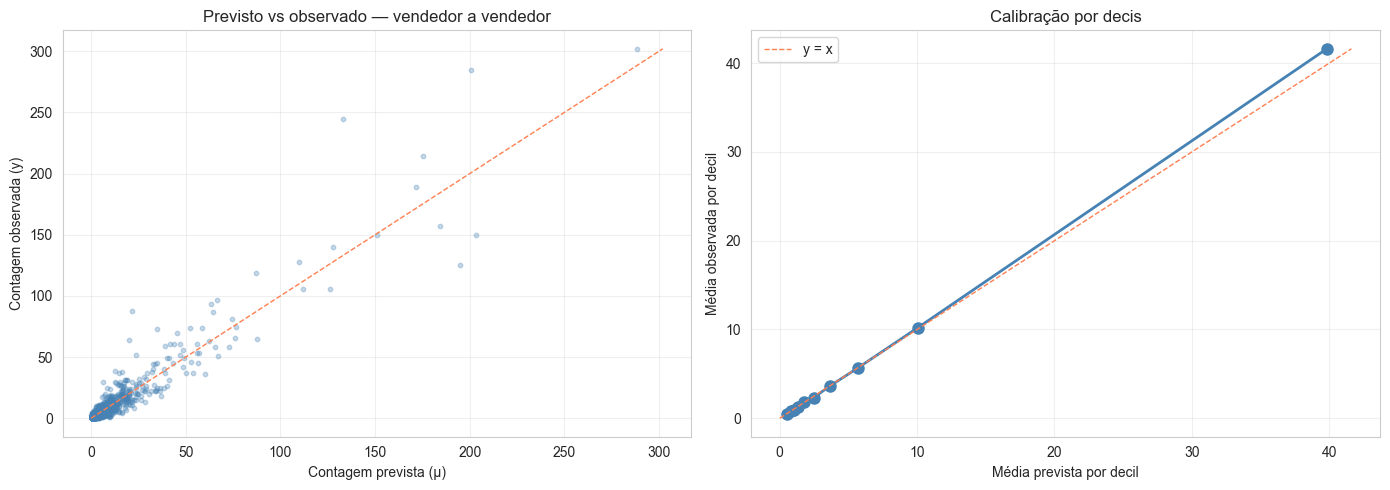

In [6]:
_mu_pred = _negbin.predict(_X_red, exposure=np.exp(_offset))

_df_cal = pd.DataFrame({"y": _y.values, "mu": np.asarray(_mu_pred)})
_df_cal["decil"] = pd.qcut(_df_cal["mu"], q=10, labels=False, duplicates="drop")
_agg = _df_cal.groupby("decil").agg(mu_medio=("mu", "mean"), y_medio=("y", "mean")).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(_mu_pred, _y, alpha=0.3, s=10, color="steelblue")
_lim = max(float(_mu_pred.max()), float(_y.max()))
axes[0].plot([0, _lim], [0, _lim], color="coral", linestyle="--", linewidth=1)
axes[0].set_xlabel("Contagem prevista (μ)"); axes[0].set_ylabel("Contagem observada (y)")
axes[0].set_title("Previsto vs observado — vendedor a vendedor"); axes[0].grid(True, alpha=0.3)

axes[1].plot(_agg["mu_medio"], _agg["y_medio"], "o-", color="steelblue", markersize=8, linewidth=2)
_lim2 = max(_agg["mu_medio"].max(), _agg["y_medio"].max())
axes[1].plot([0, _lim2], [0, _lim2], color="coral", linestyle="--", linewidth=1, label="y = x")
axes[1].set_xlabel("Média prevista por decil"); axes[1].set_ylabel("Média observada por decil")
axes[1].set_title("Calibração por decis"); axes[1].grid(True, alpha=0.3); axes[1].legend()
plt.tight_layout()
plt.savefig("../outputs/fig_calibracao.png", dpi=120, bbox_inches="tight")
plt.show()


## 6. Simulação contrafactual — redução do atraso

Traduz o coeficiente do atraso em consequência operacional. Considerando os vendedores observados, aplica reduções uniformes ao atraso médio e compara o total de reviews negativos previsto com o cenário base.

 delta_dias  total_previsto  reducao_pct
         -1    11301.873393     4.257940
         -2    10820.646435     8.334579
         -3    10359.909831    12.237637
         -5     9496.454966    19.552261
         -7     8704.965428    26.257241


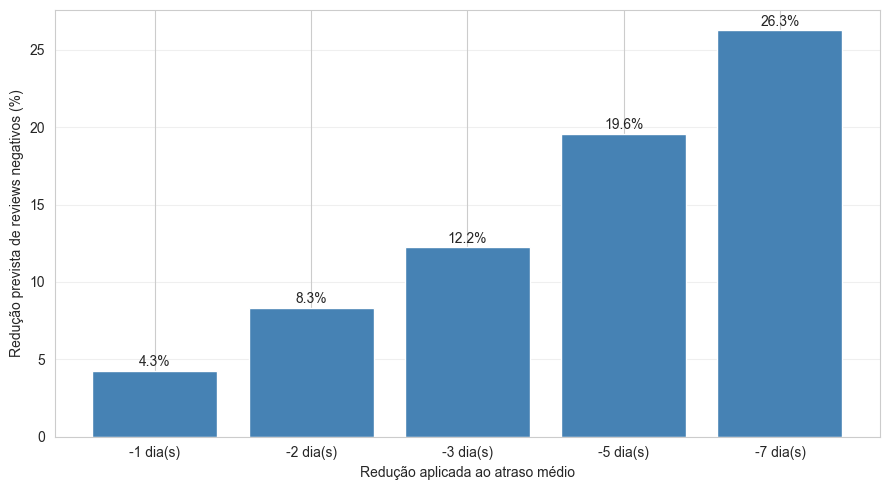

In [7]:
_cenarios = [-1, -2, -3, -5, -7]
_pred_base = _negbin.predict(_X_red, exposure=np.exp(_offset))
_base_total = float(_pred_base.sum())

linhas = []
for delta in _cenarios:
    _X_sim = _X_red.copy()
    _X_sim["atraso_medio"] = _X_sim["atraso_medio"] + delta
    _pred_novo = _negbin.predict(_X_sim, exposure=np.exp(_offset))
    _total_novo = float(_pred_novo.sum())
    _reducao = _base_total - _total_novo
    _pct = _reducao / _base_total * 100
    linhas.append({"delta_dias": delta, "total_previsto": _total_novo, "reducao_pct": _pct})

contraf = pd.DataFrame(linhas)
print(contraf.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
_barras = ax.bar([f"{int(d)} dia(s)" for d in contraf["delta_dias"]], contraf["reducao_pct"],
                  color="steelblue", edgecolor="white")
for b, val in zip(_barras, contraf["reducao_pct"]):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.3, f"{val:.1f}%", ha="center", fontsize=10)
ax.set_xlabel("Redução aplicada ao atraso médio"); ax.set_ylabel("Redução prevista de reviews negativos (%)")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("../outputs/fig_contrafactual.png", dpi=120, bbox_inches="tight")
plt.show()


## 7. Diagnóstico dos resíduos

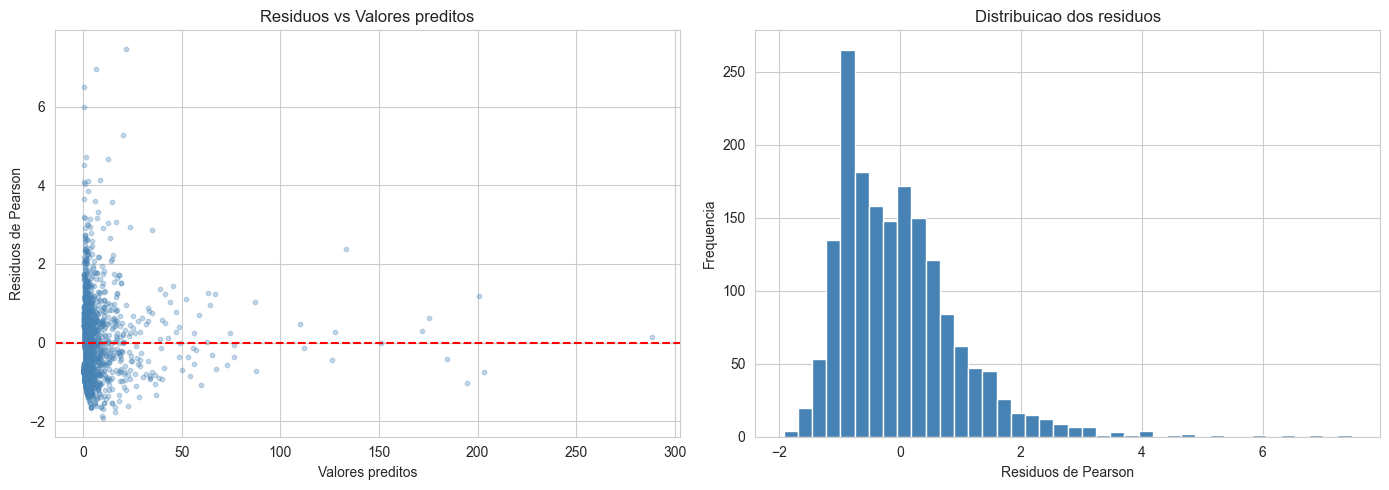

Pearson chi2/df: 1.0506


In [8]:
# Reestimar modelo para diagnostico de residuos
cat_counts = df["categoria_principal"].value_counts()
cats_keep = cat_counts[cat_counts >= 30].index.tolist()
df["cat_group"] = df["categoria_principal"].where(df["categoria_principal"].isin(cats_keep), "other")
st_counts = df["seller_state"].value_counts()
st_keep = st_counts[st_counts >= 30].index.tolist()
df["state_group"] = df["seller_state"].where(df["seller_state"].isin(st_keep), "other")
df["log_n_reviews"] = np.log(df["n_reviews"])
df_model = df[["n_negative","log_n_reviews","atraso_medio","ticket_medio",
               "frete_medio","peso_medio","cat_group","state_group"]].copy()
df_model = pd.get_dummies(df_model, columns=["cat_group","state_group"], dtype=int)
# Remover dummies de referencia
df_model = df_model.drop(columns=["cat_group_sports_leisure", "state_group_SP"])

y = df_model["n_negative"]
offset = df_model["log_n_reviews"]
X_full = df_model.drop(columns=["n_negative","log_n_reviews"])
X_full = sm.add_constant(X_full)

# Variaveis do modelo final (excluindo nao-significativas)
vars_final = list(coefs.index)
X_red = X_full[[c for c in X_full.columns if c in vars_final]]

negbin_diag = NB_MLE(y, X_red, exposure=np.exp(offset)).fit(method="bfgs", maxiter=500, disp=False)

mu_pred = negbin_diag.predict(X_red, exposure=np.exp(offset))
alpha_d = negbin_diag.params["alpha"]
pearson_r = (y - mu_pred) / np.sqrt(mu_pred + alpha_d * mu_pred**2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(mu_pred, pearson_r, alpha=0.3, s=10, color="steelblue")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Valores preditos")
axes[0].set_ylabel("Residuos de Pearson")
axes[0].set_title("Residuos vs Valores preditos")

axes[1].hist(pearson_r, bins=40, color="steelblue", edgecolor="white")
axes[1].set_xlabel("Residuos de Pearson")
axes[1].set_ylabel("Frequencia")
axes[1].set_title("Distribuicao dos residuos")

plt.tight_layout()
plt.savefig("../outputs/interp_diagnostico_residuos.png", bbox_inches="tight", dpi=100)
plt.show()
pearson_chi2_df = metricas["negbin_reduzido"]["pearson_chi2_df"]
print(f"Pearson chi2/df: {pearson_chi2_df:.4f}")

## 8. Pseudo R2 (Cox-Snell e McFadden)

Medidas de qualidade de ajuste relativo do modelo NB2 reduzido. Valores baixos sao esperados em modelos de contagem com dados cross-section de elevada heterogeneidade individual (Hilbe, 2011).

In [9]:
cs = 1 - np.exp(2 * (negbin_diag.llnull - negbin_diag.llf) / len(y))
mcf = 1 - negbin_diag.llf / negbin_diag.llnull
print(f"Pseudo R2 de Cox-Snell (NB2 reduzido): {cs:.4f}")
print(f"Pseudo R2 de McFadden (NB2 reduzido):  {mcf:.4f}")


Pseudo R2 de Cox-Snell (NB2 reduzido): 0.1014
Pseudo R2 de McFadden (NB2 reduzido):  0.0262


## 9. Observacoes influentes e robustez do modelo

Identificacao dos vendedores com maiores residuos de Pearson (pior ajuste) e reestimacao do modelo sem esses pontos, para verificar se as conclusoes dependem de poucos outliers.

In [10]:
df_diag = df.loc[y.index].copy()
df_diag["pearson_r"] = np.asarray(pearson_r)
top_out = df_diag.assign(ap=df_diag["pearson_r"].abs()).sort_values("ap", ascending=False).head(10)
print("10 vendedores com maiores residuos de Pearson:")
print(top_out[["n_reviews", "n_negative", "atraso_medio", "frete_medio", "categoria_principal"]].round(2).to_string())

top_idx = top_out.index
negbin_robust = NB_MLE(y.drop(top_idx), X_red.drop(top_idx), exposure=np.exp(offset).drop(top_idx)).fit(method="bfgs", maxiter=500, disp=False)
rob = pd.DataFrame({"coef_completo": negbin_diag.params, "coef_sem_top10": negbin_robust.params})
rob["exp_completo"] = np.exp(rob["coef_completo"])
rob["exp_sem_top10"] = np.exp(rob["coef_sem_top10"])
print("\nEstabilidade dos coeficientes (completo vs sem os 10 maiores residuos):")
print(rob.drop(index=["alpha"], errors="ignore").round(4).to_string())


10 vendedores com maiores residuos de Pearson:
      n_reviews  n_negative  atraso_medio  frete_medio categoria_principal
324         183          88         -9.96        15.89       watches_gifts
936          91          30        -22.55        21.41           perfumery
1753          8           3        -48.00        17.23                auto
554           6           4        -27.14        23.88    air_conditioning
200         107          64         -6.67        14.74           telephony
456          11           7        -15.50        54.67                auto
797         128          39        -21.74        28.53     furniture_decor
1126          8           4        -23.12        19.69        garden_tools
1281         65          25         -8.97        19.90                baby
1262         62          10        -43.62        40.95     furniture_decor

Estabilidade dos coeficientes (completo vs sem os 10 maiores residuos):
                                 coef_completo  coef_se

## 10. Validacao cruzada (5-fold)

Validacao cruzada com 5 particoes para avaliar a capacidade de generalizacao do modelo. Compara o NB2 reduzido com o Poisson de mesma especificacao e com um baseline ingenuo (media de treino). Como NB2 e Poisson compartilham a mesma estrutura de media condicional, espera-se erro de predicao pontual semelhante entre eles; o ganho do NB2 esta na inferencia correta sob sobredispersao, nao na predicao pontual.

In [11]:
from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
nb_mae, nb_rmse, po_mae, nv_mae = [], [], [], []
for tr, te in kf.split(X_red):
    Xtr, Xte = X_red.iloc[tr], X_red.iloc[te]
    ytr, yte = y.iloc[tr], y.iloc[te]
    otr, ote = np.exp(offset.iloc[tr]), np.exp(offset.iloc[te])
    nbm = NB_MLE(ytr, Xtr, exposure=otr).fit(method="bfgs", maxiter=500, disp=False)
    p = nbm.predict(Xte, exposure=ote)
    nb_mae.append(np.mean(np.abs(yte - p))); nb_rmse.append(np.sqrt(np.mean((yte - p) ** 2)))
    pm = sm.GLM(ytr, Xtr, family=sm.families.Poisson(), offset=np.log(otr)).fit()
    pp = pm.predict(Xte, offset=np.log(ote)); po_mae.append(np.mean(np.abs(yte - pp)))
    nv_mae.append(np.mean(np.abs(yte - ytr.mean())))

print(f"NB2 reduzido   : MAE {np.mean(nb_mae):.3f} (+/- {np.std(nb_mae):.3f}) | RMSE {np.mean(nb_rmse):.3f}")
print(f"Poisson        : MAE {np.mean(po_mae):.3f}")
print(f"Baseline media : MAE {np.mean(nv_mae):.3f}")


NB2 reduzido   : MAE 2.455 (+/- 0.246) | RMSE 6.065
Poisson        : MAE 2.458
Baseline media : MAE 7.970


## 11. Resumo

In [12]:
print("=" * 60)
print("RESUMO DOS RESULTADOS")
print("=" * 60)

print(f"\n1. SOBREDISPERSAO")
print(f"   Var/Media = {y.var()/y.mean():.2f}")
print(f"   Cameron-Trivedi p = {metricas['cameron_trivedi']['p_value']:.2e}")

print(f"\n2. MODELO SELECIONADO: Binomial Negativa")
print(f"   AIC: {metricas['negbin_reduzido']['aic']:.2f}")
print(f"   BIC: {metricas['negbin_reduzido']['bic']:.2f}")
print(f"   Pearson chi2/df: {metricas['negbin_reduzido']['pearson_chi2_df']:.4f}")

print(f"\n3. ASSOCIACOES COM A TAXA DE REVIEWS NEGATIVOS")
for idx, row in interp.iterrows():
    direcao = "associado a aumento de" if row["pct_change"] > 0 else "associado a reducao de"
    print(f"   {idx}: {direcao} {abs(row['pct_change']):.1f}% na taxa de reviews negativos")

RESUMO DOS RESULTADOS

1. SOBREDISPERSAO
   Var/Media = 52.90
   Cameron-Trivedi p = 2.31e-15

2. MODELO SELECIONADO: Binomial Negativa
   AIC: 6976.66
   BIC: 7020.41
   Pearson chi2/df: 1.0506

3. ASSOCIACOES COM A TAXA DE REVIEWS NEGATIVOS
   cat_group_telephony: associado a aumento de 38.2% na taxa de reviews negativos
   cat_group_bed_bath_table: associado a aumento de 33.4% na taxa de reviews negativos
   cat_group_furniture_decor: associado a aumento de 29.2% na taxa de reviews negativos
   cat_group_computers_accessories: associado a aumento de 20.8% na taxa de reviews negativos
   atraso_medio: associado a aumento de 4.4% na taxa de reviews negativos
   frete_medio: associado a aumento de 0.6% na taxa de reviews negativos
